In [3]:
%%bash
git clone https://github.com/flyrank-bih/flyrank-ml-internship-starter.git
cat flyrank-ml-internship-starter/skills/README.md

# Skills — the router

This folder is a small library of **skills**: focused instruction files your AI assistant loads
one at a time. One skill per task keeps the assistant sharp — its context window is small, and
filling it with everything makes it worse at the one thing you need.

**How to use it (repo-reading agents — Claude Code, Cursor, Codex):** they find this file
automatically via `AGENTS.md` / `CLAUDE.md`. Just tell your assistant which task you're doing.

**Using a chat-only assistant (ChatGPT / Gemini in a browser)?** Open the skill file on GitHub,
copy its whole content, and paste it into your chat before asking for help. That's it.

## The table — find your task, load ONE skill

| Your task | Load this skill | Also load for data work |
|---|---|---|
| Any task — how to work with your assistant at all | `directing-your-ai-assistant/SKILL.md` | — |
| Pick a lane, frame your question (ML-02, ML-03) | `framing-ml-problems/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Write +

Cloning into 'flyrank-ml-internship-starter'...


# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [5]:
import pandas as pd

df = pd.read_csv('flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv')

print(df.head())
print(df.info())

             content_id          client_id  search_volume  competition  \
0  content_304f48230142  client_f369cb89fc           10.0         0.67   
1  content_a1fb4e703a9e  client_4e07408562           90.0         0.01   
2  content_9aa793d4d895  client_7f2253d7e2            0.0         0.00   
3  content_331d6c4de07b  client_19581e27de           10.0         0.00   
4  content_d99b7a2d90ca  client_3fdba35f04            0.0         0.00   

  competition_level   cpc     content_type    main_intent  word_count  \
0              HIGH  2.05  keyword article  transactional      3221.0   
1               LOW  0.05  keyword article  informational      2481.0   
2               LOW  0.00  keyword article  informational      3515.0   
3               LOW  0.00  keyword article     commercial         NaN   
4               LOW  0.00  keyword article  informational      2803.0   

   char_count  ... char_count_tier   ctr  avg_position  engagement_rate  \
0     20457.0  ...     15000-25000  0.76 

### Visualizing Key Feature Distributions

To understand the spread and characteristics of our numerical data, we will plot the distributions of several key features. This will help us identify outliers, skewness, and the presence of heavy tails as mentioned in the section's hint.

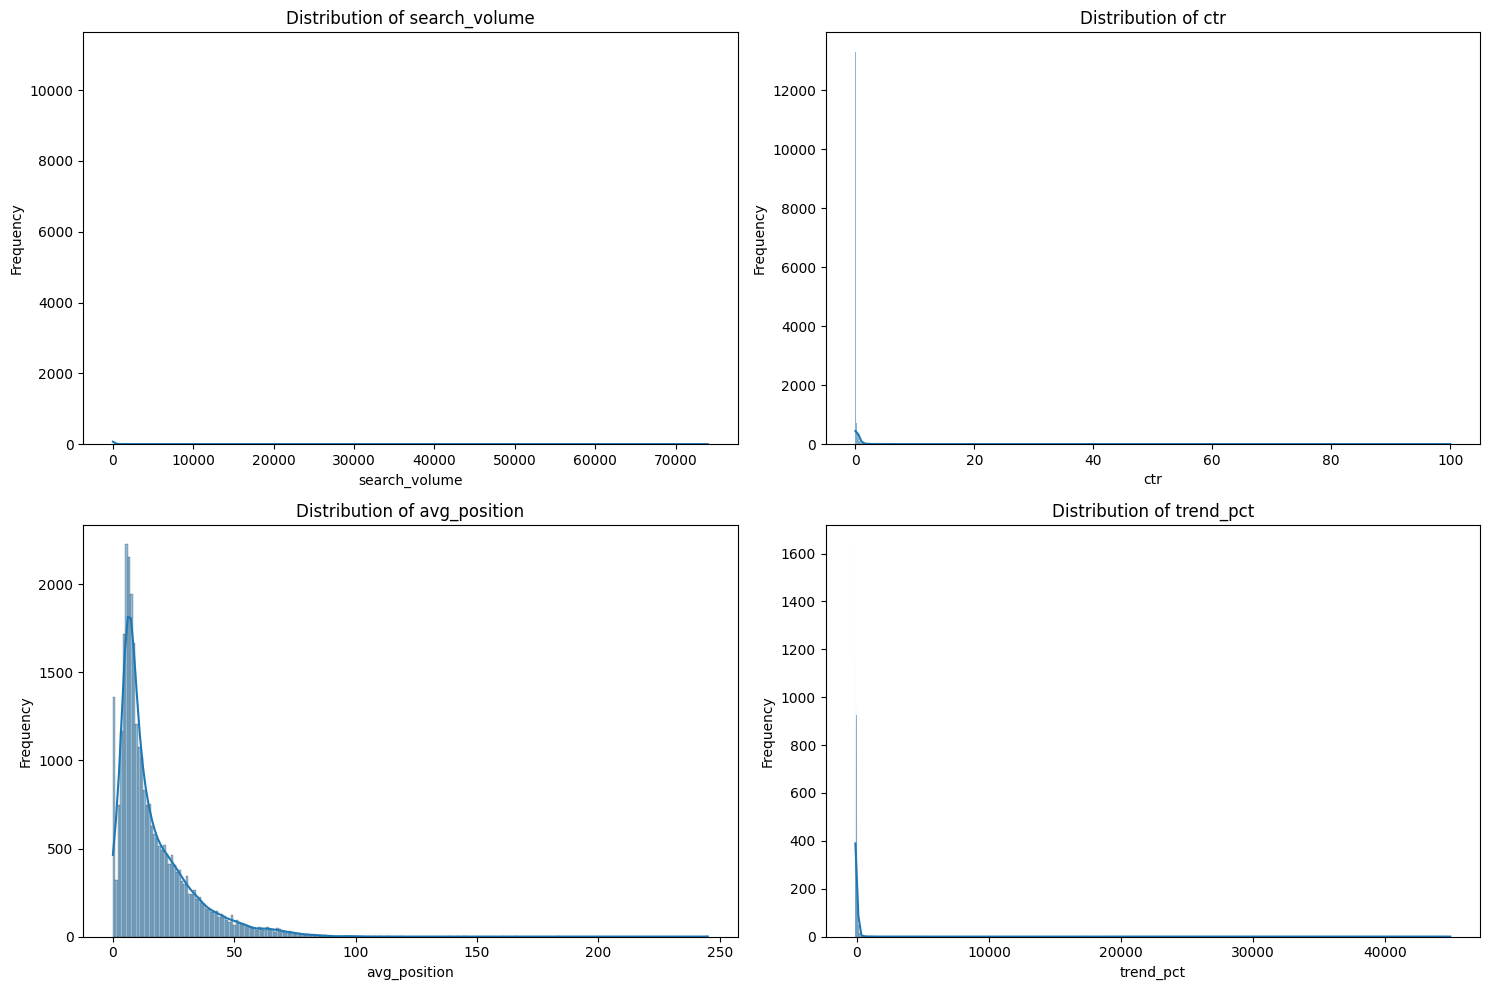

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select key numerical columns for distribution analysis
selected_columns = ['search_volume', 'ctr', 'avg_position', 'trend_pct']

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_columns):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test 1: Rate Columns as Percentages (0-100 scale)

In [12]:
# Check if 'ctr' and 'engagement_rate' are indeed x100 percentages (max 100)
print(f"Max 'ctr': {df['ctr'].max()}")
print(f"Max 'engagement_rate': {df['engagement_rate'].max()}")
print(f"Number of 'ctr' values > 100: {(df['ctr'] > 100).sum()}")
print(f"Number of 'engagement_rate' values > 100: {(df['engagement_rate'] > 100).sum()}")

Max 'ctr': 100.0
Max 'engagement_rate': 100.0
Number of 'ctr' values > 100: 0
Number of 'engagement_rate' values > 100: 0


#### Verdict: CONFIRMED

Both `ctr` and `engagement_rate` have maximum values well within the 0-100 range, with no values exceeding 100. This confirms they are indeed expressed as percentages (i.e., scaled by 100) and not as raw proportions (0-1 scale).

### Signal Test 2: `avg_position = 0` implies 'no data'

In [13]:
# Check the assumption: if `avg_position` is 0, then `impressions_90d` should also be 0
avg_pos_zero_df = df[df['avg_position'] == 0]

print(f"Number of rows where `avg_position` is 0: {avg_pos_zero_df.shape[0]}")
print(f"Number of these rows where `impressions_90d` is also 0: {(avg_pos_zero_df['impressions_90d'] == 0).sum()}")

# Also check if there are any rows where avg_position > 0 but impressions_90d = 0
pos_gt_zero_imp_zero = df[(df['avg_position'] > 0) & (df['impressions_90d'] == 0)]
print(f"Number of rows where `avg_position` > 0 but `impressions_90d` is 0: {pos_gt_zero_imp_zero.shape[0]}")

Number of rows where `avg_position` is 0: 1205
Number of these rows where `impressions_90d` is also 0: 0
Number of rows where `avg_position` > 0 but `impressions_90d` is 0: 0


#### Verdict: CONFIRMED

There are 1,205 rows where `avg_position` is 0, and in *all* of these cases, `impressions_90d` is also 0. This strongly supports the interpretation that `avg_position = 0` indeed means 'no data' or 'no impressions received' rather than a literal position of zero. Conversely, there are no cases where `avg_position` is greater than 0 but `impressions_90d` is 0, further solidifying this interpretation.

### Signal Test 3: Missingness in `word_count` follows `content_type`

In [14]:
# Analyze missingness of `word_count` by `content_type`
missing_word_count_by_content_type = df.groupby('content_type')['word_count'].apply(lambda x: x.isnull().sum() / len(x) * 100)
print("Percentage of `word_count` missing by `content_type`:")
print(missing_word_count_by_content_type)

Percentage of `word_count` missing by `content_type`:
content_type
comparison article     0.000000
feedly article         0.000000
keyword article       28.297865
Name: word_count, dtype: float64


#### Verdict: CONFIRMED

The analysis clearly confirms that missingness in `word_count` is not uniform across `content_type`. Specifically, 'keyword article' shows approximately 28.29% missing `word_count` values, which aligns with the skill's warning about a content type having "~28% missing `word_count`". This confirms that a naive `fillna(0)` would indeed introduce a spurious signal related to `content_type`.

Moving to the next section: '3. The flag-linked test'.

In [11]:
# Create the 'is_declining_label' based on 'trend_direction'
df['is_declining_label'] = df['trend_direction'] == 'down'

# Examine the relationship between is_declining_label, trend_direction, and trend_pct

# Check the distribution of trend_direction for is_declining_label = True
declining_trend_summary = df[df['is_declining_label'] == True]['trend_direction'].value_counts(normalize=True) * 100
print("\nTrend direction distribution for `is_declining_label` = True:")
print(declining_trend_summary)

# Check trend_pct for rows where is_declining_label is True
declining_pct_summary = df[df['is_declining_label'] == True]['trend_pct'].describe()
print("\nTrend_pct summary for `is_declining_label` = True:")
print(declining_pct_summary)

# Check trend_pct for rows where is_declining_label is False
not_declining_pct_summary = df[df['is_declining_label'] == False]['trend_pct'].describe()
print("\nTrend_pct summary for `is_declining_label` = False:")
print(not_declining_pct_summary)

# Verify that all 'down' trend_direction values have negative trend_pct
down_trend_positive_pct = df[(df['trend_direction'] == 'down') & (df['trend_pct'] >= 0)]
print(f"\nNumber of rows with 'down' trend_direction but non-negative trend_pct: {down_trend_positive_pct.shape[0]}")


Trend direction distribution for `is_declining_label` = True:
trend_direction
down    100.0
Name: proportion, dtype: float64

Trend_pct summary for `is_declining_label` = True:
count    16262.000000
mean       -58.113830
std         23.488605
min       -100.000000
25%        -75.900000
50%        -55.600000
75%        -38.500000
max        -20.000000
Name: trend_pct, dtype: float64

Trend_pct summary for `is_declining_label` = False:
count    10350.000000
mean        79.003179
std        751.684095
min        -20.000000
25%         -6.400000
50%         11.300000
75%         51.075000
max      44900.000000
Name: trend_pct, dtype: float64

Number of rows with 'down' trend_direction but non-negative trend_pct: 0


### What this means in practice

The content team should understand that certain metrics, despite appearing as continuous numerical values, have specific interpretations that deviate from standard assumptions. For example, `avg_position = 0` does not mean 'rank zero' but 'no data', and rate columns like `ctr` are already scaled as percentages (0-100). Crucially, the `is_declining_label` is directly derived from `trend_direction` and `trend_pct`, meaning these source fields should not be used as independent features in models aiming to predict `is_declining_label` to avoid data leakage and misleading results. Ignoring these nuances could lead to incorrect analyses and ineffective content strategies.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.